In [1]:
import os
import shutil
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [2]:
classes = [
    'banten_dogdoglojor', 'jakarta_tehyan',
    'jawabarat_angklung', 'jawabarat_calung', 'jawabarat_celempung', 'jawabarat_gong',
    'jawabarat_karinding', 'jawabarat_kecapi', 'jawabarat_rebab', 'jawabarat_suling',
    'jawabarat_tarawangsa', 'jawatengah_bonang', 'jawatengah_demung', 'jawatengah_siter',
    'jawatimur_kluncing', 'jawatimur_saronen', 'yogjakarta_kendang'
]
base_path = 'datasetfixcsul'
split_base = 'split_datasetfixcsul'
splits = ['train', 'val', 'test']
split_ratio = {'train': 0.8, 'val': 0.1, 'test': 0.1}

# Buat folder split
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(split_base, split, cls), exist_ok=True)

# Proses bagi untuk setiap kelas
for cls in classes:
    src_dir = os.path.join(base_path, cls)
    all_images = [os.path.join(src_dir, img) for img in os.listdir(src_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    random.shuffle(all_images)
    total = len(all_images)
    train_end = int(split_ratio['train'] * total)
    val_end = train_end + int(split_ratio['val'] * total)

    split_data = {
        'train': all_images[:train_end],
        'val': all_images[train_end:val_end],
        'test': all_images[val_end:]
    }

    for split in splits:
        for img_path in split_data[split]:
            shutil.copy(img_path, os.path.join(split_base, split, cls, os.path.basename(img_path)))

print("Dataset berhasil dibagi")


Dataset berhasil dibagi


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2,
                                   horizontal_flip=True, shear_range=0.2)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(split_base, 'train'),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(split_base, 'val'),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(split_base, 'test'),
    target_size=(img_size, img_size),
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

Found 2720 images belonging to 17 classes.
Found 340 images belonging to 17 classes.
Found 340 images belonging to 17 classes.


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(17, activation='softmax')(x)  # 5 kelas

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,279,761 (8.70 MB)

 Trainable params: 21,777 (85.07 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=35
)

c:\Users\bagus\Kuliah\Semester 8\Skripsi\apkskrip\pcd_resnet50\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35
85/85 ━━━━━━━━━━━━━━━━━━━━ 582s 7s/step - accuracy: 0.3115 - loss: 2.4181 - val_accuracy: 0.9029 - val_loss: 0.4378
Epoch 2/35
85/85 ━━━━━━━━━━━━━━━━━━━━ 300s 4s/step - accuracy: 0.8571 - loss: 0.5122 - val_accuracy: 0.9618 - val_loss: 0.2184
Epoch 3/35
85/85 ━━━━━━━━━━━━━━━━━━━━ 303s 4s/step - accuracy: 0.9278 - loss: 0.2718 - val_accuracy: 0.9765 - val_loss: 0.1342
Epoch 4/35
85/85 ━━━━━━━━━━━━━━━━━━━━ 288s 3s/step - accuracy: 0.9496 - loss: 0.2022 - val_accuracy: 0.9853 - val_loss: 0.0891
Epoch 5/35
85/85 ━━━━━━━━━━━━━━━━━━━━ 297s 4s/step - accuracy: 0.9572 - loss: 0.1605 - val_accuracy: 0.9912 - val_loss: 0.0672
Epoch 6/35
85/85 ━━━━━━━━━━━━━━━━━━━━ 278s 3s/step - accuracy: 0.9608 - loss: 0.1372 - val_accuracy: 0.9941 - val_loss: 0.0505
Epoch 7/35
85/85 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 0.9698 - loss: 0.1088 - val_accuracy: 0.9912 - val_loss: 0.0473
Epoch 8/35
85/85 ━━━━━━━━━━━━━━━━━━━━ 281s 3s/step - accuracy: 0.9671 - loss: 0.1228 - val_accuracy: 0.9971 - v

In [6]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Akurasi pada test set: {test_acc:.2%}")

340/340 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.9985 - loss: 0.0042
Akurasi pada test set: 99.71%


In [7]:
# Tampilkan nilai akhir dari training dan validasi
final_training_loss = history.history['loss'][-1]
final_training_accuracy = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

print("Training Loss:", final_training_loss)
print("Training Accuracy:", final_training_accuracy)
print("Val Loss:", final_val_loss)
print("Val Accuracy:", final_val_accuracy)

Training Loss: 0.02450844831764698
Training Accuracy: 0.9922794103622437
Val Loss: 0.004416818730533123
Val Accuracy: 1.0


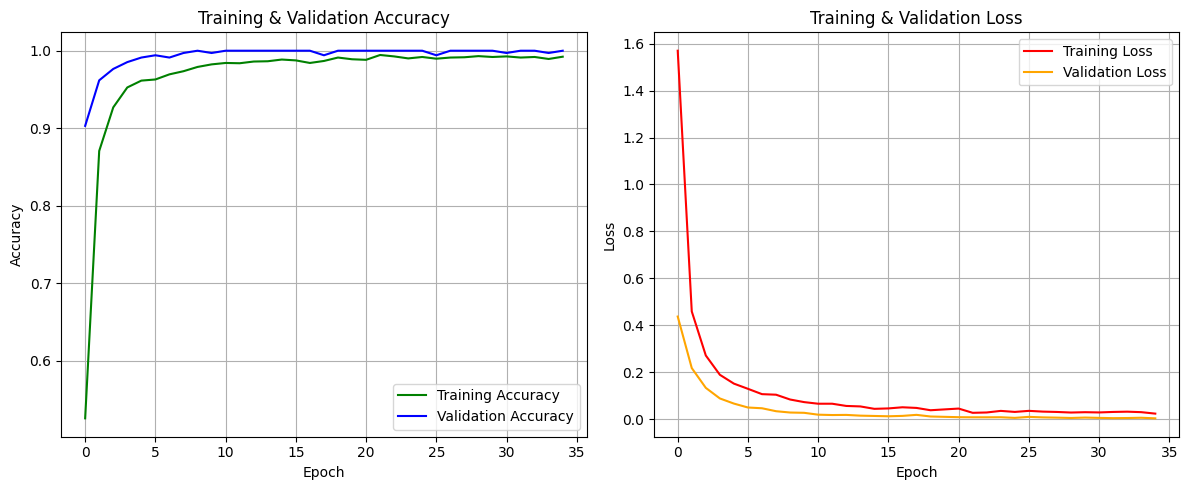

In [8]:
import matplotlib.pyplot as plt

# Visualisasi Akurasi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Visualisasi Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

340/340 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step


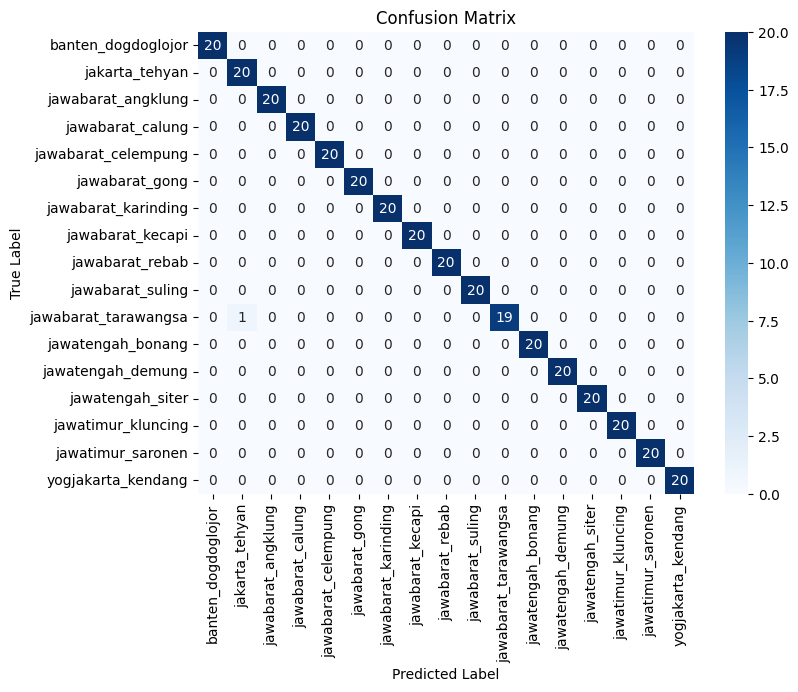

Classification Report:
                      precision    recall  f1-score   support

  banten_dogdoglojor       1.00      1.00      1.00        20
      jakarta_tehyan       0.95      1.00      0.98        20
  jawabarat_angklung       1.00      1.00      1.00        20
    jawabarat_calung       1.00      1.00      1.00        20
 jawabarat_celempung       1.00      1.00      1.00        20
      jawabarat_gong       1.00      1.00      1.00        20
 jawabarat_karinding       1.00      1.00      1.00        20
    jawabarat_kecapi       1.00      1.00      1.00        20
     jawabarat_rebab       1.00      1.00      1.00        20
    jawabarat_suling       1.00      1.00      1.00        20
jawabarat_tarawangsa       1.00      0.95      0.97        20
   jawatengah_bonang       1.00      1.00      1.00        20
   jawatengah_demung       1.00      1.00      1.00        20
    jawatengah_siter       1.00      1.00      1.00        20
  jawatimur_kluncing       1.00      1.00     

In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

In [11]:
model.save('modelalatmusikmobnetv2snew.h5')
print("Model berhasil disimpan'")

Model berhasil disimpan'


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


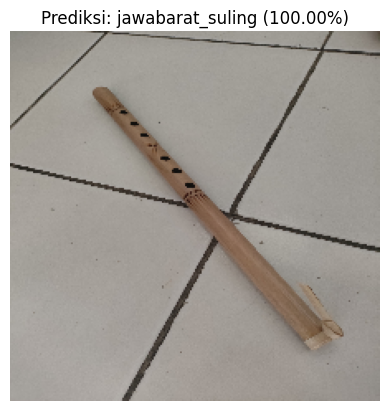


Prediksi: jawabarat_suling (100.00%)


In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# --- Konfigurasi ---
model_path = 'modelalatmusikmobnetv2snew.h5'  # Path ke model MobileNetV2 kamu
img_path = 'split_datasetfixcsul/test/jawabarat_suling/IMG_20250716_110018.jpg'               # Gambar yang ingin diuji
img_size = 224                            # Ukuran input model
threshold = 0.6                           # Confidence threshold

# --- Load model ---
model = load_model(model_path)

# --- Load dan preprocess gambar ---
img = image.load_img(img_path, target_size=(img_size, img_size))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# --- Prediksi ---
pred = model.predict(img_array)
confidence = np.max(pred)
class_idx = np.argmax(pred, axis=1)[0]

# --- Daftar kelas alat musik ---
class_labels = [
    'banten_dogdoglojor', 'jakarta_tehyan',
    'jawabarat_angklung', 'jawabarat_calung', 'jawabarat_celempung', 'jawabarat_gong',
    'jawabarat_karinding', 'jawabarat_kecapi', 'jawabarat_rebab', 'jawabarat_suling',
    'jawabarat_tarawangsa', 'jawatengah_bonang', 'jawatengah_demung', 'jawatengah_siter',
    'jawatimur_kluncing', 'jawatimur_saronen', 'yogjakarta_kendang'
]

predicted_class = class_labels[class_idx]

# --- Tampilkan gambar ---
plt.imshow(img)
plt.title(f"Prediksi: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis('off')
plt.show()

# --- Tampilkan hasil prediksi ---
if confidence < threshold:
    print(f"\n⚠️ Confidence rendah. Prediksi mungkin kurang akurat.")
    print(f"Prediksi: {predicted_class} ({confidence * 100:.2f}%)")
else:
    print(f"\nPrediksi: {predicted_class} ({confidence * 100:.2f}%)")


In [14]:
import tensorflow as tf

# Load model dari file .keras
model = tf.keras.models.load_model("modelalatmusikmobnetv2snew.h5")

# Konversi ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
# Simpan sebagai file .tflite
with open("modelalatmusikmobnetv2snew.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Konversi selesai: modelalatmusikmobnetv2snew.tflite")

INFO:tensorflow:Assets written to: C:\Users\bagus\AppData\Local\Temp\tmpu0v0jf1w\assets


INFO:tensorflow:Assets written to: C:\Users\bagus\AppData\Local\Temp\tmpu0v0jf1w\assets


Saved artifact at 'C:\Users\bagus\AppData\Local\Temp\tmpu0v0jf1w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  1367673880208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1367673879248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1367673879056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1367673879632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1367673877904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1367673880016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1367673876368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1367673877712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1367673880400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1367673874832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13676